In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.model_selection import train_test_split

In [20]:
df1 = pd.read_parquet("../raw/train-00000-of-00001.parquet")
df2 = pd.read_parquet("../raw/test-00000-of-00001.parquet")
df3 = pd.read_parquet("../raw/validation-00000-of-00001.parquet")

In [21]:
df1.head()

,tweet_text,class_label
0,Powerful Ecuador quake kills at least 235: POR...,injured_or_dead_people
1,Im at awe and saddened with the #EcuadorEarthq...,rescue_volunteering_or_donation_effort
2,RT @RachelAndJun: Our hearts are with everyone...,sympathy_and_support
3,RT @noticias2000: Ecuador quake death toll has...,injured_or_dead_people
4,RT @pzf: BREAKING PHOTOS: Major damage reporte...,infrastructure_and_utility_damage


In [22]:
df1['class_label'].unique()

<ArrowStringArray>
[                'injured_or_dead_people',
 'rescue_volunteering_or_donation_effort',
                   'sympathy_and_support',
      'infrastructure_and_utility_damage',
               'requests_or_urgent_needs',
             'other_relevant_information',
                     'caution_and_advice',
                       'not_humanitarian',
       'displaced_people_and_evacuations',
                'missing_or_found_people']
Length: 10, dtype: str

#### merging the document

In [23]:
df = pd.concat([df1,df2,df3], ignore_index=True) # merging or concatnating the three datasets together.

In [24]:
df.shape

(76484, 2)

#### distribution check

In [25]:
df['class_label'].value_counts()

class_label
rescue_volunteering_or_donation_effort    21278
other_relevant_information                12144
sympathy_and_support                       8931
infrastructure_and_utility_damage          8163
injured_or_dead_people                     7303
not_humanitarian                           6296
caution_and_advice                         5394
displaced_people_and_evacuations           3999
requests_or_urgent_needs                   2618
missing_or_found_people                     358
Name: count, dtype: int64

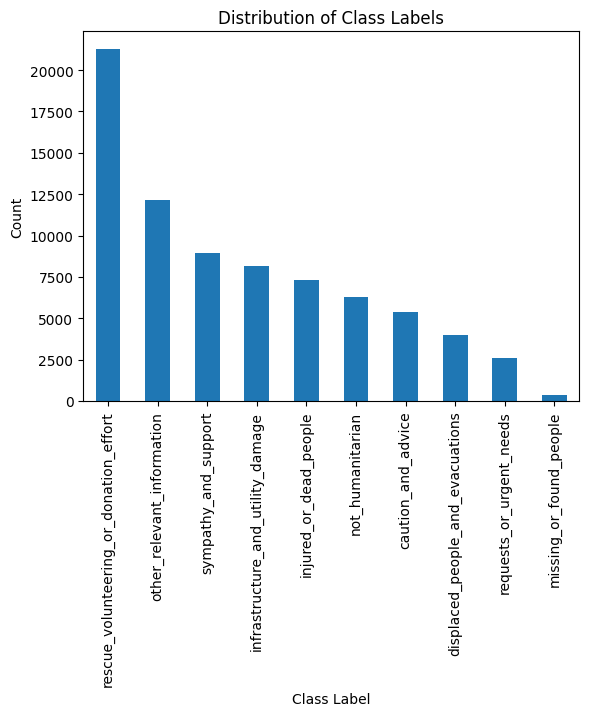

In [33]:
df['class_label'].value_counts().plot(kind='bar')
plt.title('Distribution of Class Labels')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76484 entries, 0 to 76483
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   tweet_text   76484 non-null  str  
 1   class_label  76484 non-null  str  
dtypes: str(2)
memory usage: 13.6 MB


In [30]:
df[df['class_label'].isnull()]

,tweet_text,class_label


In [31]:
df.isnull().sum()

tweet_text     0
class_label    0
dtype: int64

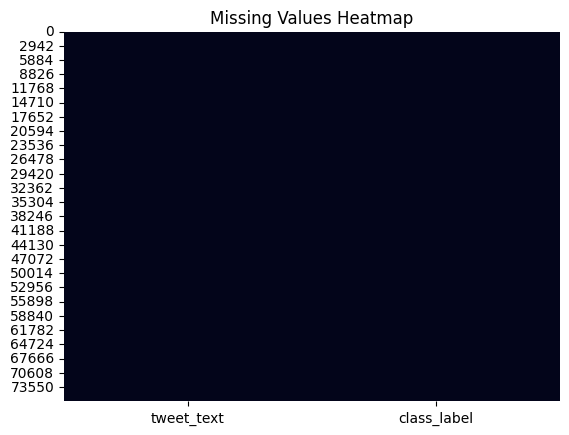

In [34]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [36]:
duplicqates = df.duplicated().sum()
print("duplicqates:", duplicqates)

duplicqates: 6


In [ ]:
df[df.duplicated(subset=['tweet_text'], keep=False)] # duplicates in column tweet_text.

,tweet_text,class_label
22478,Keep these in your prayers tonight: - Earthqua...,sympathy_and_support
24842,Lady Gaga will be donating $1M to relief effor...,rescue_volunteering_or_donation_effort
24987,RT @landovela1: Pray for Mexico they just had ...,sympathy_and_support
25206,RT @MerrellTwins: Our thoughts &amp; prayers a...,sympathy_and_support
59504,RT @MLB: MLB to donate $1 million to assist co...,rescue_volunteering_or_donation_effort
60566,RT @MLB: MLB to donate $1 million to assist co...,rescue_volunteering_or_donation_effort
71549,RT @cher: We ὤFἿB4 Those Suffering From Devast...,infrastructure_and_utility_damage
71830,RT @landovela1: Pray for Mexico they just had ...,sympathy_and_support
71900,RT @MerrellTwins: Our thoughts &amp; prayers a...,sympathy_and_support
72073,Lady Gaga will be donating $1M to relief effor...,rescue_volunteering_or_donation_effort


In [43]:
df = df.drop_duplicates()

In [ ]:
df.shape #six arity removed which are duplicates

(76478, 2)